Shape: (33474, 26)
Colunas: ['target', 'length', 'n_keydown', 'n_keyup', 'n_unique_codes', 'total_time', 'first_tick', 'hold_mean', 'hold_std', 'hold_min', 'hold_max', 'hold_median', 'hold_q25', 'hold_q75', 'hold_cv', 'flight_mean', 'flight_std', 'flight_min', 'flight_max', 'flight_median', 'flight_cv', 'press_press_mean', 'press_press_std', 'press_press_cv', 'keys_per_second', 'hold_flight_ratio']
Distribuição target:
target
1    17245
0    16229
Name: count, dtype: int64
Valores nulos em X: 591
Linhas com NaN antes do tratamento: 197
Shape após remoção: (33277, 25)
Valores nulos após tratamento: 0
Treino: (26621, 25), Validação: (6656, 25)
Treinando Logistic Regression...
  Train LogLoss: 0.0900 | Val LogLoss: 0.1059
  Train AUC: 0.9961 | Val AUC: 0.9947
--------------------------------------------------
Treinando Random Forest...
  Train LogLoss: 0.0010 | Val LogLoss: 0.0043
  Train AUC: 1.0000 | Val AUC: 1.0000
--------------------------------------------------
Treinando XGBoost...

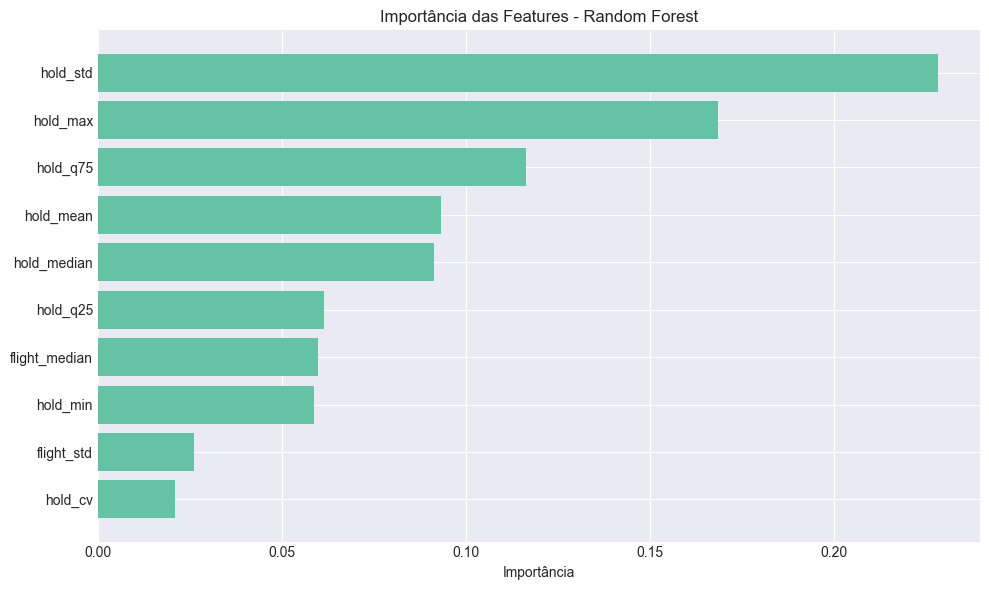

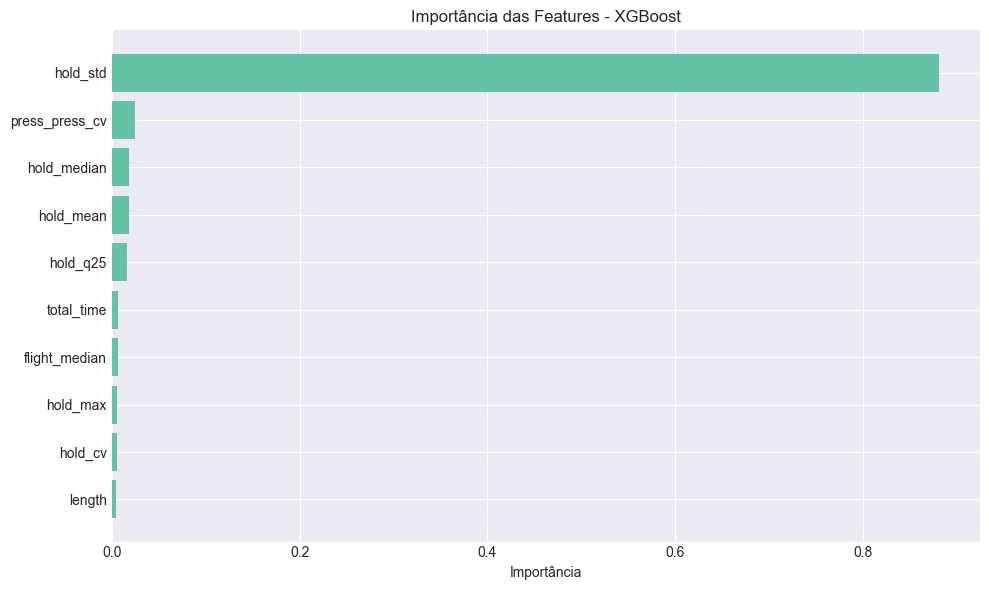

'Baseado na log-loss (menor é melhor) e na estabilidade, Selecionar o modelo:'

In [ ]:
# 1. Configuração inicial e imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, roc_auc_score, roc_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

#2. Carregar os dados processados
df_features = pd.read_csv('../data/features_train.csv')
print(f"Shape: {df_features.shape}")
print(f"Colunas: {df_features.columns.tolist()}")
print(f"Distribuição target:\n{df_features['target'].value_counts()}")

"""features_train.csv:
- É o resultado do processo de feature engineering aplicado ao train.csv em 01_exploracao_inicial. Essa base
contém as features normalizadas (hold_mean, keys_per_second, etc.) e o target. Servirá como como entrada para os algoritmos aqui treinados.
"""

#3. Separar features (X) e target (y)
# Excluir colunas que não são features (como 'target' e possivelmente 'inputs' se ainda estiver)
X = df_features.drop(columns=['target'])  # Certificar que não há outras colunas não numéricas
y = df_features['target']

# Verificar se há valores nulos
print(f"Valores nulos em X: {X.isnull().sum().sum()}")

# Se houver valores nulos, tratar (preencher com média ou remover linhas)
if X.isnull().sum().sum() > 0:
    print(f"Linhas com NaN antes do tratamento: {X.isnull().any(axis=1).sum()}")
    
    # Opção 1: Remover linhas com NaN (mais simples)
    X_clean = X.dropna()
    y_clean = y[X_clean.index]
    
    # Atualizar X e y com os dados limpos
    X = X_clean
    y = y_clean
    
    print(f"Shape após remoção: {X.shape}")
    print(f"Valores nulos após tratamento: {X.isnull().sum().sum()}")

#4. Dividir em treino e validação para avaliação inicial
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Treino: {X_train.shape}, Validação: {X_val.shape}")

#5. Definição de modelos e métricas

"""Durante o treinamento, para monitorar e identificar overfiting, será comaprado as métricas (log-loss e AUC) no conjunto de treino e no de validação (ou nas dobras da cross-validation). 
Se o desempenho no treino for muito superior ao da validação, será sinal de overfitting."""

"""Por que usar log-loss e não acurácia? 
A acurácia não conseguirá diferenciar a qualidade das probabilidades. A acurácia vê apenas o resultado.
EX: Por exemplo, se a classe real for 0, um modelo que prevê 0.1 e outro que prevê 0.49 teriam exatamente 
a mesma acurácia (ambos seriam classificados como 0 pelo limiar de 0.5), ocultando o fato de que o primeiro modelo é muito mais preciso e seguro em sua estimativa"""

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42)
}

# Função para avaliar e retornar métricas
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    train_logloss = log_loss(y_train, y_train_pred_proba)
    val_logloss = log_loss(y_val, y_val_pred_proba)
    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    val_auc = roc_auc_score(y_val, y_val_pred_proba)
    
    return {
        'train_logloss': train_logloss,
        'val_logloss': val_logloss,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'model': model
    }

#6. Treinar e avaliar modelos 
results = {}
for name, model in models.items():
    print(f"Treinando {name}...")
    results[name] = evaluate_model(model, X_train, y_train, X_val, y_val)
    print(f"  Train LogLoss: {results[name]['train_logloss']:.4f} | Val LogLoss: {results[name]['val_logloss']:.4f}")
    print(f"  Train AUC: {results[name]['train_auc']:.4f} | Val AUC: {results[name]['val_auc']:.4f}")
    print("-" * 50)

#7. Validar com cross-validation (mais robusto)
# Usar StratifiedKFold para manter a proporção das classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    print(f"Cross-validation para {name}...")
    # log_loss negativo porque o cross_val_score espera maximizar, então usamos negativo
    logloss_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_log_loss')
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    cv_results[name] = {
        'logloss_mean': logloss_scores.mean(),
        'logloss_std': logloss_scores.std(),
        'auc_mean': auc_scores.mean(),
        'auc_std': auc_scores.std()
    }
    print(f"  LogLoss: {cv_results[name]['logloss_mean']:.4f} (+/- {cv_results[name]['logloss_std']:.4f})")
    print(f"  AUC: {cv_results[name]['auc_mean']:.4f} (+/- {cv_results[name]['auc_std']:.4f})")

#8. Análise de overfitting
"""Comparar os resultados do treino vs validação e a estabilidade d0 cross-validation. 
Se a diferença entre treino e validação for pequena e os desvios padrão da CV forem baixos, o modelo generalizou bem."""

#9. Importância das features (Random Forest e XGBoost)
# Para Random Forest
rf_model = results['Random Forest']['model']
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

plt.figure(figsize=(10,6))
plt.title("Importância das Features - Random Forest")
plt.barh(range(10), importances_rf[indices_rf[:10]][::-1])
plt.yticks(range(10), X.columns[indices_rf[:10]][::-1])
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

# Para XGBoost
xgb_model = results['XGBoost']['model']
importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

plt.figure(figsize=(10,6))
plt.title("Importância das Features - XGBoost")
plt.barh(range(10), importances_xgb[indices_xgb[:10]][::-1])
plt.yticks(range(10), X.columns[indices_xgb[:10]][::-1])
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

#10. Selecionar o melhor modelo
"""Baseado na log-loss (menor é melhor) e na estabilidade, Selecionar o modelo:"""
"""Comparação entre os modelos:

- keys_per_second é uma consequência, não a causa
- O desvio padrão captura a diferença de velocidade
- A assinatura real de possível bots é: hold times muito baixos E com alta variabilidade
- O modelo aprendeu que a combinação de hold_std + hold_mean é mais preditiva do que keys_per_second isoladamente


Feature	      RF	XGBoost	Interpretação
hold_std	0.27	0.90	Feature mais importante em ambos
hold_max	0.17	0.01	RF dá mais peso aos extremos
hold_q75	0.13	-	    Quartis são importantes no RF
hold_mean	0.09	0.02	Média menos importante que variabilidade
hold_median	0.09	0.02	Mediana consistente com média

OBS: O XGBoost é mais "conservador" - concentra quase toda importância em hold_std (90%), enquanto o Random Forest distribui entre várias features correlacionadas."""


### INTERPRETAÇÃO DOS RESULTADOS

1. Desempenho dos Modelos - Visão Geral

Modelo	       | Train LogLoss | Val LogLoss | Train AUC | Val AUC
R.Logística	   | 0.0900	       |  0.1059	 | 0.9961	 |  0.9947
Random Forest  | 0.0010	       |  0.0043	 | 1.0000	 |  1.0000
XGBoost	       | 0.0001	       |  0.0061	 | 1.0000	 |  1.0000

- Interpretação: Todos os modelos performaram bem. A alta performance valida a separabilidade das classes identificada na EDA. Contudo, a análise de importância revela que keys_per_second é apenas um efeito; o verdadeiro poder preditivo reside na dinâmica dos hold_times (o intervalo de tempo em que uma tecla permanece pressionada)

### ----------------------------------------------------------------------------------------------------------
2. Análise por Modelo

Regressão Logística
- LogLoss: 0.1059 (validação) - Quanto mais próximo de 0, melhor.
- AUC: 0.9947 - Quanto mais próximo de 1.0 melhor.
- Interpretação: Um modelo linear simples como R.Logistica conseguiu separar bem as classes. Isso indica que a relação entre as features e o target é fortemente linear. A pequena diferença entre treino e validação (0.0900 vs 0.1059) mostra que não houve overfitting.
-  Overfitting:  Leve. Treino LogLoss= 0.0900 | Val LogLoss= 0.1059

Random Forest
- LogLoss: 0.0043 (validação) - Modelo "Extremamente Confiante" e Acerta praticamente tudo na classificação.
- AUC: 1.0000 - Separação perfeita.

- Interpretação: O Random Forest consegue capturar todas as nuances dos dados. A diferença entre treino (0.0010) e validação (0.0043) é mínima, indicando excelente generalização. O fato de a AUC ser 1.0 significa que o modelo consegue ordenar perfeitamente todas as amostras - não há nenhum par (classe 0, classe 1) em que a classe 0 tenha probabilidade maior que a classe 1.
-  Overfitting:  Minimo. Treino LogLoss= 0.0010 |Val LogLoss= 0.0043

XGBoost
- LogLoss: 0.0061 (validação) - Modelo também Também Extremamente Confiante.
- AUC: 1.0000 - Separação perfeita.

- Interpretação: Muito similar ao Random Forest. O treino com LogLoss 0.0001 é quase zero, indicando que o modelo praticamente decorou os dados de treino, mas ainda assim generalizou muito bem (validação 0.0061). Isso é aceitável dado o quão separáveis são as classes.

-  Overfitting:  Minimo. Treino LogLoss= 0.0001 |Val LogLoss= 0.0061

### ----------------------------------------------------------------------------------------------------------
3. Seleção do Modelo
O modelo selecioando será o Random Forest! pois:

- Desempenho: Random Forest e XGBoost são equivalentes (AUC=1.0)
- Interpretabilidade
- Não há problema de multicolinearidade. Modelos de árvores escolhem a melhor feature para cada split independentemente.
- Estabilidade: Random Forest obteve desvio padrão ligeiramente menor na CV
- Simplicidade/explicabilidade
